# SKIN DISORDER

## Problem Statement
Buil a multi-class classification model to predict the type of skin disease using clinical and histopathological features.

**Goal:** Helps doctors identify disease at an early stage.

## Data Analysis Report

1. **Dataset Overview**
*   Records : 366 patients
*   Attributes : 34 input features + 1 target feature
*   Target variable : class (6 skin disease catagories)
*   Feature Types :
    *   Clinical symptoms (erythema, itching, scaling, etc.)
    *   Histopathological findings (acanthosis, hyperkeratosis, Munro microabscess, etc.)
    *   Patient age
* Disease class:
  
    1. Psoriasis
    2. Seborrheic Dermatitis
    3. Lichen Planus
    4. Pityriasis Rosea
    5. Chronic Dermatities
    6. Pityriasis Rubra Pilaris

2. **Data Quality and Preprocessing**
*   Missing values contain only in attribute of Age(?) , replace with median imputer
*   No categorical encoding required
*   All symptom features are ordinal (0-3 scale)
*   Dataset is balanced enough for multiclass learning










## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import *

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


from xgboost import XGBClassifier

## Load dataset

In [2]:
skin_df = pd.read_csv('dataset_35_dermatology (1).csv')
skin_df

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3


## Basic Checks

In [3]:
# Show first 5 rows of the dataset
skin_df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [4]:
# Show last 5 rows from the dataset
skin_df.tail()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35,1


In [5]:
# Summary of the entire dataframe
skin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [6]:
# Statistical summary of the numerical data
skin_df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [7]:
# Shape of the dataset
skin_df.shape

(366, 35)

## Data Cleaning & Preprocessing

In [8]:
# Check duplicated values
skin_df.duplicated().sum()

np.int64(0)

In [9]:
# Check missing values
skin_df.isnull().sum()

,0
erythema,0
scaling,0
definite_borders,0
itching,0
koebner_phenomenon,0
polygonal_papules,0
follicular_papules,0
oral_mucosal_involvement,0
knee_and_elbow_involvement,0
scalp_involvement,0


In [10]:
skin_df['Age'].unique()

array(['55', '8', '26', '40', '45', '41', '18', '57', '22', '30', '20',
       '21', '10', '65', '38', '23', '17', '51', '42', '44', '33', '43',
       '50', '34', '?', '15', '46', '62', '35', '48', '12', '52', '60',
       '32', '19', '29', '25', '36', '13', '27', '31', '28', '64', '39',
       '47', '16', '0', '7', '70', '37', '61', '67', '56', '53', '24',
       '58', '49', '63', '68', '9', '75'], dtype=object)

In [11]:
# Age column contain missing values(?) replace into median
skin_df['Age'] = skin_df['Age'].replace('?', np.nan)

skin_df['Age'].isnull().sum()

np.int64(8)

In [12]:
skin_df['Age'].dtypes

dtype('O')

In [13]:
# Impute the missing value with median
skin_df['Age'] = skin_df['Age'].astype(float)
skin_df['Age'] = skin_df['Age'].fillna(skin_df['Age'].median())

In [14]:
skin_df['Age'].dtypes

dtype('float64')

In [15]:
skin_df['Age'].describe()

,Age
count,366.000000
mean,36.267760
std,15.156875
min,0.000000
25%,25.000000
50%,35.000000
75%,48.000000
max,75.000000


In [16]:
# Check target distribution
skin_df['class'].value_counts()

,count
class,
1,112
3,72
2,61
5,52
4,49
6,20


## Exploratory Data Analysis - EDA

Disease Class Mapping It's Easy To We Identify The Disease (For Report Purpose)

In [17]:
disease_map = {
    1: "Psoriasis",
    2: "Seborrheic Dermatitis",
    3: "Lichen Planus",
    4: "Pityriasis Rosea",
    5: "Chronic Dermatitis",
    6: "Pityriasis Rubra Pilaris"
}

skin_df['Disease_Name'] = skin_df['class'].map(disease_map)
skin_df['Disease_Name']

,Disease_Name
0,Seborrheic Dermatitis
1,Psoriasis
2,Lichen Planus
3,Psoriasis
4,Lichen Planus
...,...
361,Pityriasis Rosea
362,Pityriasis Rosea
363,Lichen Planus
364,Lichen Planus


1. Outlier Detection

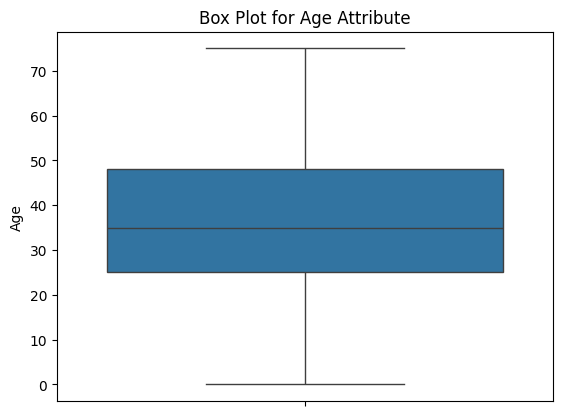

In [18]:
# Box Plot
sns.boxplot(skin_df['Age'])
plt.title('Box Plot for Age Attribute')
plt.show()

This dataset does not contain significant outliers. Most features are ordinal severity scores with fixed medical ranges, and the continuous Age feature contains only clinically valid values. Therefore, outlier removal is neither required nor recommended.

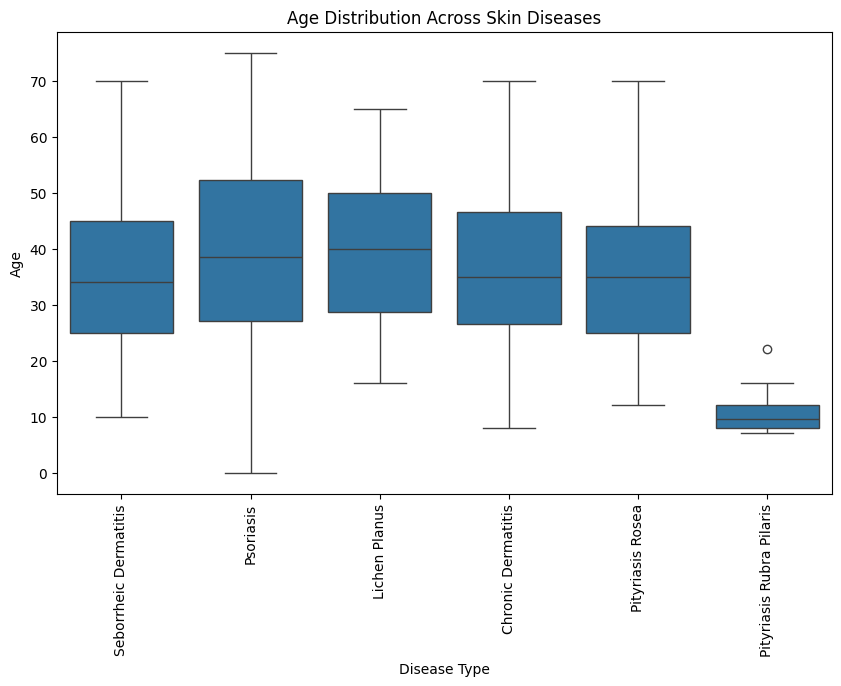

In [19]:
# Age Distribution by Disease (Boxplot)

plt.figure(figsize = (10, 6))
sns.boxplot(x="Disease_Name", y="Age", data=skin_df)
plt.xticks(rotation=90)
plt.title("Age Distribution Across Skin Diseases")
plt.xlabel("Disease Type")
plt.ylabel("Age")
plt.show()

The boxplot illustrates the age distribution for each skin disease. It suggests that Pityriasis Rosea might be more common in younger individuals, while diseases like Psoriasis, Chronic Dermatitis, and Pityriasis Rubra Pilaris tend to have broader age ranges.

2. Target class distribution

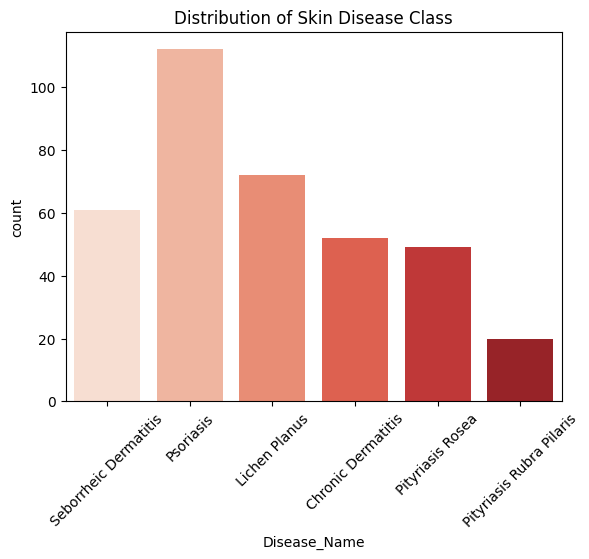

In [20]:
sns.countplot(x = 'Disease_Name', data = skin_df, palette = ('Reds'))
plt.title('Distribution of Skin Disease Class')
plt.xticks(rotation = 45)
plt.show()



*   The Dataset is reasonbly balanced. Class 1 having significantly more samples than Class 6. These difference is not a severe class imbalance.

In [21]:
distribution = skin_df['Disease_Name'].value_counts().reset_index()
distribution.columns = ['Disease', 'Patients_Count']
distribution

,Disease,Patients_Count
0,Psoriasis,112
1,Lichen Planus,72
2,Seborrheic Dermatitis,61
3,Chronic Dermatitis,52
4,Pityriasis Rosea,49
5,Pityriasis Rubra Pilaris,20


3. New Features : Age_Group

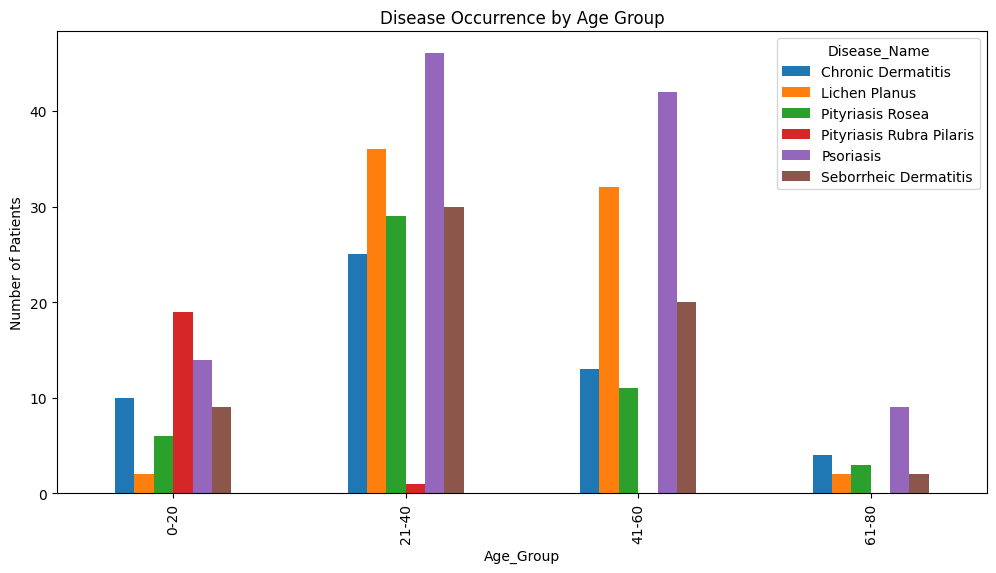

In [22]:
# Age Group Analysis

bins = [0, 20, 40, 60, 80]
labels = ["0-20", "21-40", "41-60", "61-80"]

skin_df["Age_Group"] = pd.cut(skin_df["Age"], bins=bins, labels=labels)

pd.crosstab(skin_df["Age_Group"], skin_df["Disease_Name"]).plot(kind='bar', figsize=(12,6))
plt.title("Disease Occurrence by Age Group")
plt.ylabel("Number of Patients")
plt.show()

* This cross-tabulation plot shows the distribution of different skin diseases across various age groups. It helps to identify which diseases are more prevalent in specific age ranges, such as Pityriasis Rosea in younger individuals or Psoriasis and Chronic Dermatitis across broader age groups.

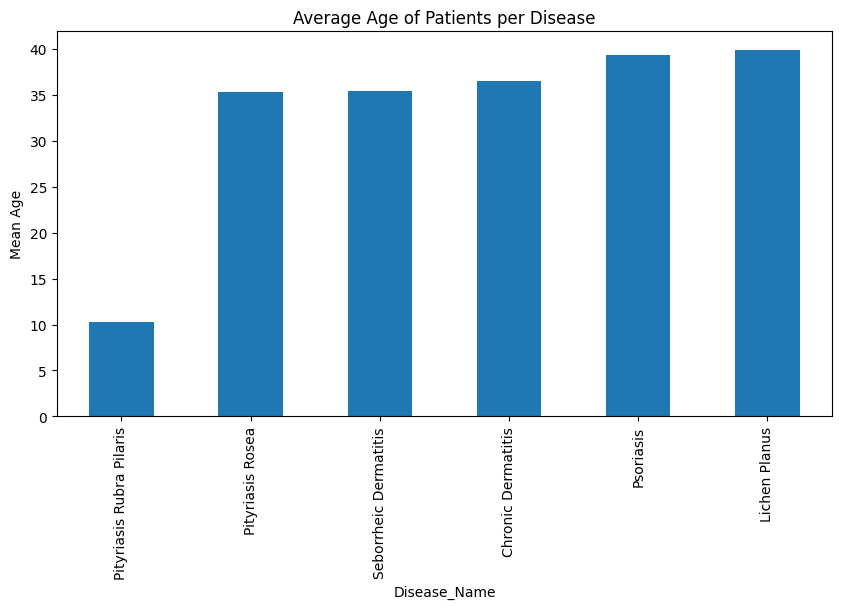

In [23]:
# Average Age per Disease
age_stats = skin_df.groupby("Disease_Name")["Age"].mean().sort_values()
age_stats.plot(kind='bar', figsize=(10,5))
plt.title("Average Age of Patients per Disease")
plt.ylabel("Mean Age")
plt.show()

* This bar plot reveals the average age of patients for each disease. It indicates that Pityriasis Rubra Pilaris tends to affect a much younger demographic, while diseases like Psoriasis and Lichen Planus have higher average ages among the patient groups. The other diseases fall in the middle age ranges.



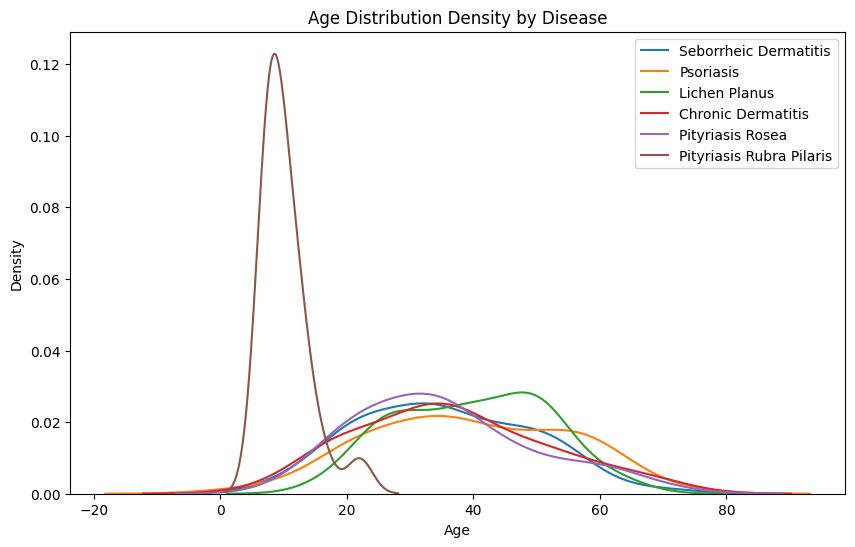

In [24]:
# Age Distribution Density

plt.figure(figsize=(10,6))

for disease in skin_df["Disease_Name"].unique():
    sns.kdeplot(skin_df[skin_df["Disease_Name"] == disease]["Age"], label=disease)

plt.title("Age Distribution Density by Disease")
plt.xlabel("Age")
plt.legend()
plt.show()

* This KDE plot shows the density distribution of age for each disease. It visually highlights which diseases are more prevalent at certain ages and the overall spread of age for each condition, providing a smoother representation than a histogram.

4. Severity Distribution of Key Symptoms

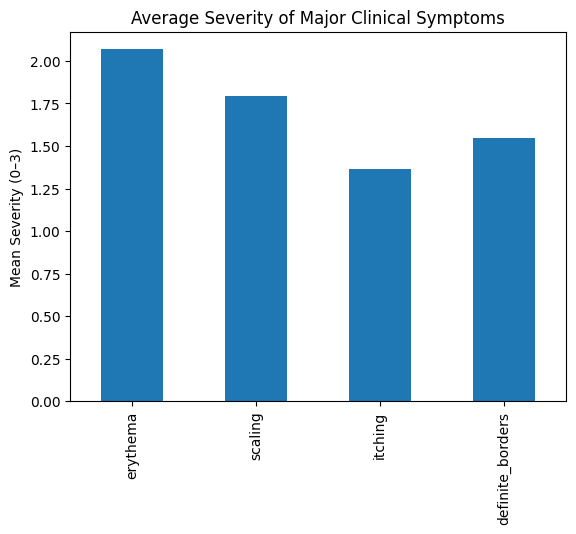

In [25]:
# Symptom Severity Patterns (eg:major clinical features)

features = ['erythema', 'scaling', 'itching', 'definite_borders']

skin_df[features].mean().plot(kind='bar')
plt.title("Average Severity of Major Clinical Symptoms")
plt.ylabel("Mean Severity (0–3)")
plt.show()

From the 'Average Severity of Major Clinical Symptoms' bar plot, we can observe that 'erythema' and 'scaling' show the highest average severity, both above 1.5. 'Itching' also has a significant average severity, while 'definite_borders' shows the lowest average severity among these selected features.

5. Histopathological Feature Importance Trends

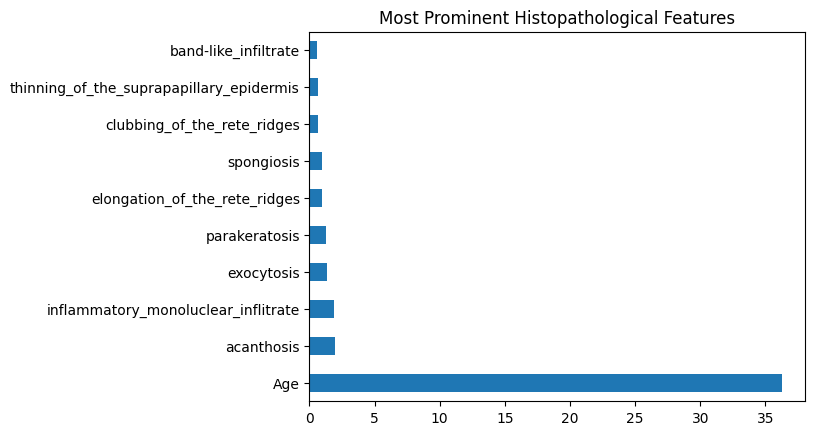

In [26]:
histopath = skin_df.columns[10:34]  # histopath features
skin_df[histopath].mean().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Most Prominent Histopathological Features")
plt.show()

This horizontal bar plot highlights the histopathological features with the highest average severity. It shows which microscopic findings are most prominent across the dataset, indicating their potential importance in characterizing different skin conditions.

6. Correlation heatmap (Feature Relationships)

In [27]:
corr = skin_df.corr(numeric_only=True)
corr

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
erythema,1.000000,0.435467,0.260087,-0.047623,0.000694,0.033571,-0.109550,-0.026810,0.141008,0.186684,...,0.159100,0.002559,0.022468,-0.005779,-0.005450,0.009539,0.075758,-0.006955,-0.003724,-0.335537
scaling,0.435467,1.000000,0.357987,-0.084197,-0.010576,-0.075035,-0.092400,-0.082969,0.298398,0.301577,...,0.211484,-0.109523,0.012151,-0.114467,-0.010518,-0.011135,-0.010977,-0.132079,0.017285,-0.468688
definite_borders,0.260087,0.357987,1.000000,-0.062564,0.241342,0.327754,-0.166662,0.286684,0.302309,0.268862,...,0.354768,0.298095,-0.255536,0.274576,-0.086250,-0.123947,0.111882,0.282578,0.137866,-0.391974
itching,-0.047623,-0.084197,-0.062564,1.000000,0.267878,0.409696,-0.144825,0.359163,-0.299645,-0.155639,...,-0.192684,0.367650,0.017514,0.376186,-0.175866,-0.184074,0.062781,0.386691,0.046546,0.054772
koebner_phenomenon,0.000694,-0.010576,0.241342,0.267878,1.000000,0.394108,-0.172741,0.392554,-0.066372,0.015202,...,0.004327,0.376473,-0.005938,0.381687,-0.147955,-0.164364,0.083358,0.382844,0.080599,-0.091323
polygonal_papules,0.033571,-0.075035,0.327754,0.409696,0.394108,1.000000,-0.137093,0.865142,-0.276058,-0.253234,...,-0.119698,0.911626,0.080063,0.895107,-0.095477,-0.110204,0.228426,0.905822,0.095935,0.057785
follicular_papules,-0.109550,-0.092400,-0.166662,-0.144825,-0.172741,-0.137093,1.000000,-0.132394,0.222255,-0.003535,...,-0.157296,-0.139960,-0.013454,-0.139141,0.785282,0.844929,-0.084864,-0.133871,-0.370436,0.477813
oral_mucosal_involvement,-0.026810,-0.082969,0.286684,0.359163,0.392554,0.865142,-0.132394,1.000000,-0.283466,-0.259813,...,-0.106704,0.887552,0.120344,0.875209,-0.082601,-0.106426,0.250937,0.892341,0.110527,0.055805
knee_and_elbow_involvement,0.141008,0.298398,0.302309,-0.299645,-0.066372,-0.276058,0.222255,-0.283466,1.000000,0.659206,...,0.481743,-0.282151,-0.413200,-0.280395,0.232903,0.257661,-0.068621,-0.276711,-0.077278,-0.383305
scalp_involvement,0.186684,0.301577,0.268862,-0.155639,0.015202,-0.253234,-0.003535,-0.259813,0.659206,1.000000,...,0.488804,-0.252483,-0.420718,-0.257210,-0.051894,-0.017352,0.035152,-0.249975,0.037349,-0.533208


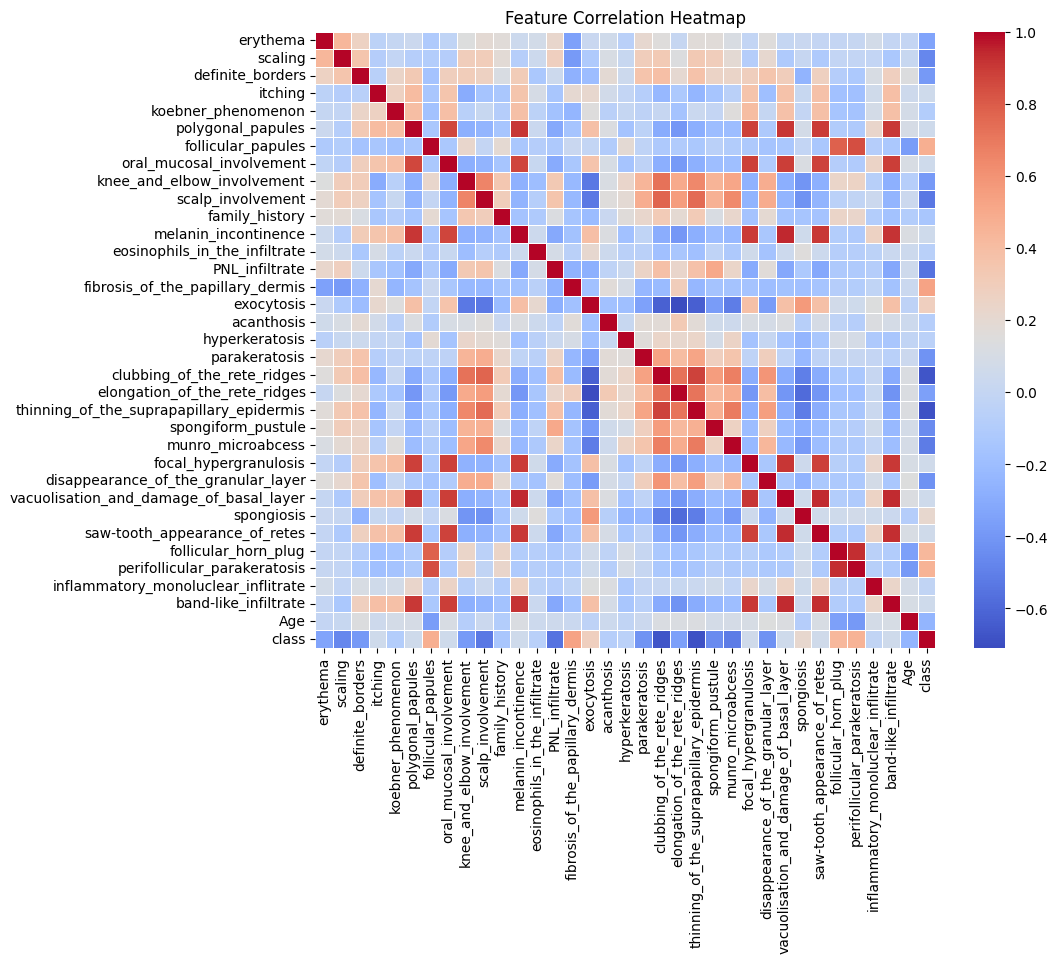

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap = 'coolwarm', linewidths = 0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Many Histopathologal features are strong coorelated, and Clinical features show moderate correlation. The tree-based model handle this well.

## Fearure Engineering

In [29]:
skin_df['Age_Group'].dtypes

CategoricalDtype(categories=['0-20', '21-40', '41-60', '61-80'], ordered=True, categories_dtype=object)

In [30]:
new_features = skin_df[['Disease_Name', 'Age_Group']]
new_features

,Disease_Name,Age_Group
0,Seborrheic Dermatitis,41-60
1,Psoriasis,0-20
2,Lichen Planus,21-40
3,Psoriasis,21-40
4,Lichen Planus,41-60
...,...,...
361,Pityriasis Rosea,21-40
362,Pityriasis Rosea,21-40
363,Lichen Planus,21-40
364,Lichen Planus,41-60


## Feature Encoding

Since all input attributes in the skin disease dataset are numerical, feature encoding is not required. However, feature scaling is applied where necessary to improve model performance.

## Feature Scaling
 * Baseline models, distance-based models required feature scaling (Standardfscaler).

 * The dermatology dataset consists of ordinal clinical and histopathological features, making tree-based models particularly suitable due to their ability to handle such data without feature scaling.

## Split Skin Disease dataset into features and target

In [31]:
x = skin_df.drop(['class', 'Disease_Name', 'Age_Group'], axis = 1)
y = skin_df['class'] - 1 # Adjust target classes to be 0-indexed

print("Modeling Features Shape: ", x.shape)

Modeling Features Shape:  (366, 34)


## Split dataset for Train and Test

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [33]:
# Check target imbalance
y_train.value_counts()

,count
class,
0,81
2,59
1,52
4,42
3,41
5,17


In [34]:
y_train.value_counts(normalize = True) * 100

,proportion
class,
0,27.739726
2,20.205479
1,17.808219
4,14.383562
3,14.041096
5,5.821918


## Model Building

**Baseline Models:**

1. **Logistic Regression:** Baseline comparison and Statistically interpretable.
2. **Naive Bayes:** Fast baseline model and Handles small datasets well.

**Tree-Based Models (Primary Models):**

1. **Decision Tree:** Easy to interpret (doctor-friendly) and Handles ordinal features naturally. Limitation is it Can overfit alone.
2. **Random Forest:** High accuracy and robustness, Handles correlated features well, Resistant to noise and outliers, and Widely accepted in medical ML.
3. **Gradient Boosting:** Learns subtle differences between similar diseases and Strong on tabular medical data.
4. **XGBoost:** State-of-the-art performance and Suitable for research-level experiments.

**Distance-Based Models:**
1. **Support Vector Machine (SVM):** Strong performance on small datasets and Good margin maximization.
2. **K-Nearest Neighbors (KNN):** Simple and intuitive. This Limitations are Sensitive to noise and Poor scalability.

**Deep Learning Model:**

1. **Multilayer Perceptron:** Learns complex non-linear interactions and Can capture subtle symptom combinations.


In [35]:
# Empty dictionary for store various models
models = {}

In [36]:
#Base line model
#Logistic Regression Model
logistic_model = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(multi_class = 'multinomial', class_weight = 'balanced', max_iter = 1000, random_state = 42))
])
models['LogisticRegression'] = logistic_model

# Naive Bayes Model
naive_bayes = GaussianNB()
models['NaiveBayes'] = naive_bayes

In [37]:
# Tree-Based Models
# Decision Tree Classifier
models['DecisionTreeClassifier'] = DecisionTreeClassifier(class_weight = 'balanced', random_state = 42)

# Random Forest Classifier
models['RandomForestClassifier'] = RandomForestClassifier(class_weight = 'balanced', n_estimators = 300, random_state = 42)

# Gradient Boosting Classifier
models['GradientBoostingClassifier'] = GradientBoostingClassifier(random_state = 42)

# XGBoost Classifier Model
models['XGBClassifer'] = XGBClassifier(
    objective = 'multi:softmax',
    num_class = 6,
    eval_metric = 'mlogloss',
    random_state = 42
)


In [38]:
# Distance=Based Models
# Suport Vector Machine
models['SupportVectorMachine'] = Pipeline([
    ('scale', StandardScaler()),
    ('model', SVC(kernel = 'rbf', probability = True, class_weight = 'balanced'))
])

# K-Nearest Neighbor(KNN)
models['KNN'] = Pipeline([
    ('scale', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors = 5))
])

In [39]:
#Deep Learning Model
# Multilayer Perceptron
models['MLP'] = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(hidden_layer_sizes = (100,), max_iter = 500, random_state = 42))
])

In [40]:
models

{'LogisticRegression': Pipeline(steps=[('scale', StandardScaler()),
                 ('model',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     multi_class='multinomial',
                                     random_state=42))]),
 'NaiveBayes': GaussianNB(),
 'DecisionTreeClassifier': DecisionTreeClassifier(class_weight='balanced', random_state=42),
 'RandomForestClassifier': RandomForestClassifier(class_weight='balanced', n_estimators=300,
                        random_state=42),
 'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
 'XGBClassifer': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_

Training and Evaluation

In [41]:
def evaluate_model(model, x_train, x_test, y_train, y_test, name):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('Actual Labels')
    plt.show()

    roc_auc = None

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(x_test)
        if y_proba.shape[1] > 2: # Multi-class classification
            roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        elif y_proba.shape[1] == 2: # Binary classification
            roc_auc = roc_auc_score(y_test, y_proba[:, 1])
    elif hasattr(model, 'decision_function'): # For SVM with decision_function
        y_score = model.decision_function(x_test)
        if y_score.ndim > 1 and y_score.shape[1] > 1: # Multi-class decision function
            roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='weighted')
        else: # Binary decision function
            roc_auc = roc_auc_score(y_test, y_score)
    else:
        print(f"Warning: ROC-AUC cannot be calculated for {name} as it lacks predict_proba or decision_function.")

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC" : roc_auc,
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

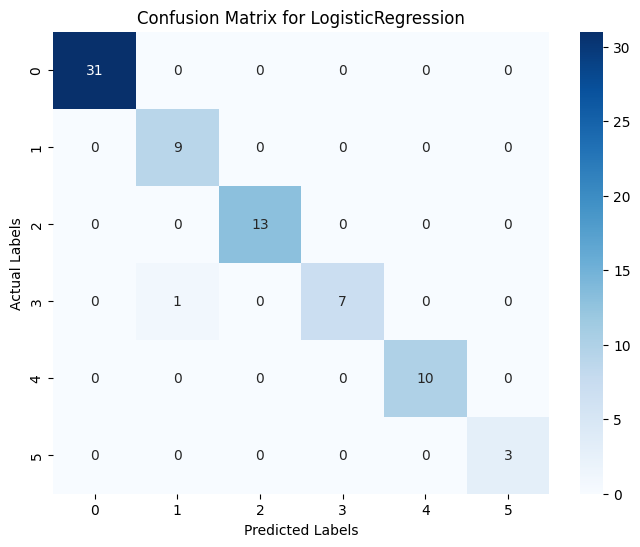

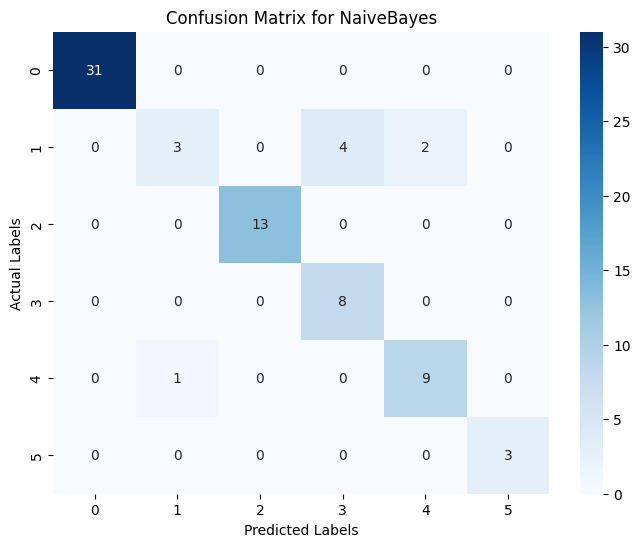

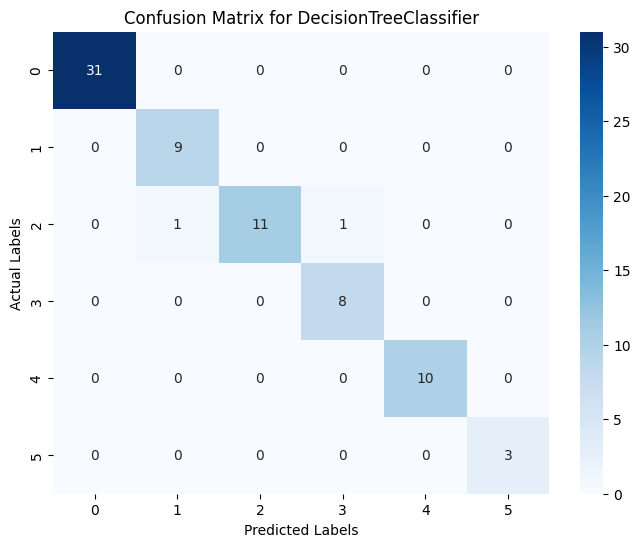

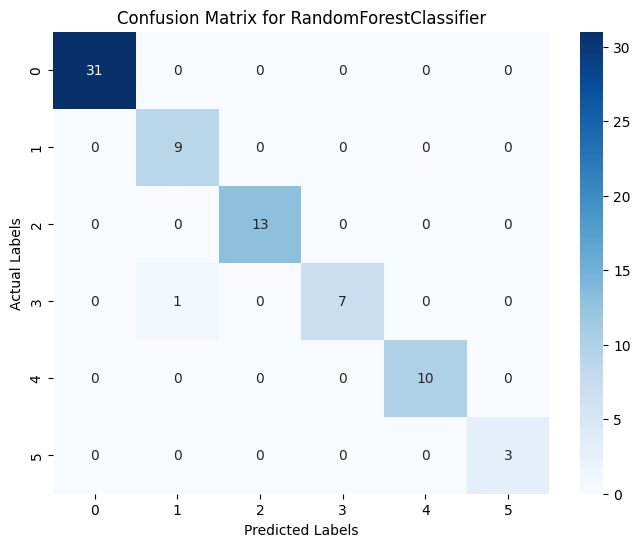

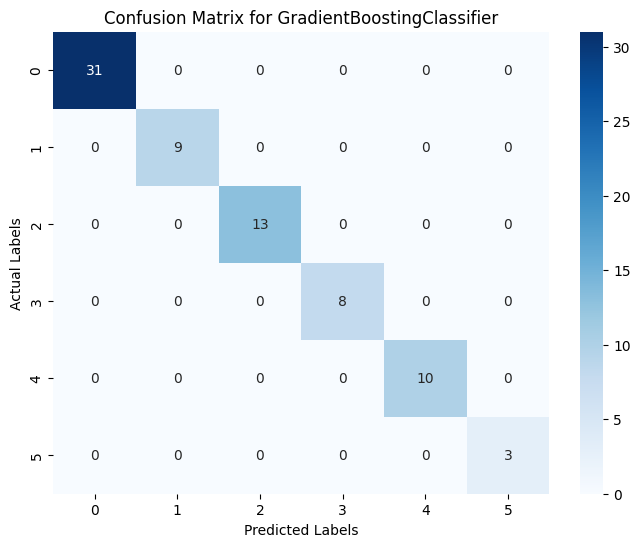

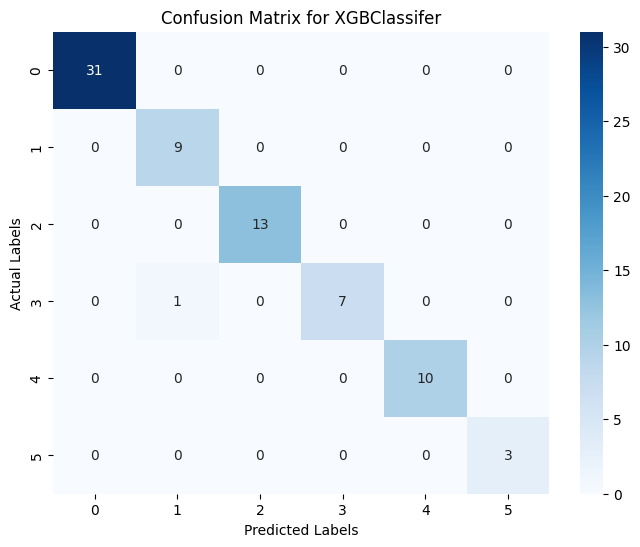

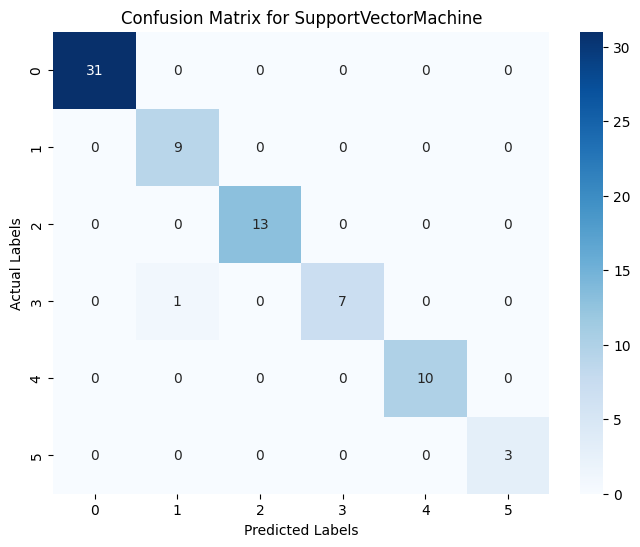

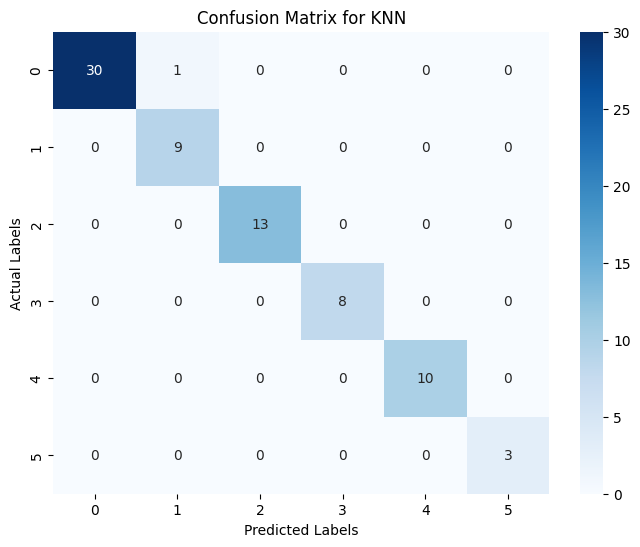

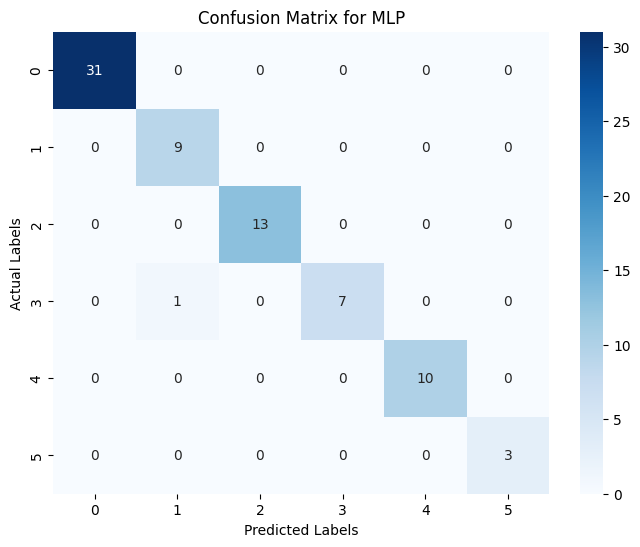

In [42]:
model_evaluation = []

for name, model in models.items():
    metrics = evaluate_model(model, x_train, x_test, y_train, y_test, name)
    metrics["Model"] = name

    model_evaluation.append(metrics)

The confusion matrices display the number of correct and incorrect predictions for each disease class. A well-performing model, like the Gradient Boosting Classifier in this case, will show high numbers along the diagonal (correct classifications) and very low or zero numbers off the diagonal (misclassifications).

In [43]:
model_eval_df = pd.DataFrame(model_evaluation)
model_eval_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Confusion Matrix,Model
0,0.986486,0.987838,0.986486,0.986392,0.998976,"[[31, 0, 0, 0, 0, 0], [0, 9, 0, 0, 0, 0], [0, ...",LogisticRegression
1,0.905405,0.908989,0.905405,0.893585,0.991473,"[[31, 0, 0, 0, 0, 0], [0, 3, 0, 4, 2, 0], [0, ...",NaiveBayes
2,0.972973,0.975826,0.972973,0.972600,0.984732,"[[31, 0, 0, 0, 0, 0], [0, 9, 0, 0, 0, 0], [0, ...",DecisionTreeClassifier
3,0.986486,0.987838,0.986486,0.986392,1.000000,"[[31, 0, 0, 0, 0, 0], [0, 9, 0, 0, 0, 0], [0, ...",RandomForestClassifier
4,1.000000,1.000000,1.000000,1.000000,1.000000,"[[31, 0, 0, 0, 0, 0], [0, 9, 0, 0, 0, 0], [0, ...",GradientBoostingClassifier
5,0.986486,0.987838,0.986486,0.986392,1.000000,"[[31, 0, 0, 0, 0, 0], [0, 9, 0, 0, 0, 0], [0, ...",XGBClassifer
6,0.986486,0.987838,0.986486,0.986392,0.999795,"[[31, 0, 0, 0, 0, 0], [0, 9, 0, 0, 0, 0], [0, ...",SupportVectorMachine
7,0.986486,0.987838,0.986486,0.986731,0.999376,"[[30, 1, 0, 0, 0, 0], [0, 9, 0, 0, 0, 0], [0, ...",KNN
8,0.986486,0.987838,0.986486,0.986392,0.999590,"[[31, 0, 0, 0, 0, 0], [0, 9, 0, 0, 0, 0], [0, ...",MLP


**Metrics Priority:**
1. Primary Metrics:

    * Recall (Sensitivity)

    * F1-Score

    * Accuracy

2. Secondary Metrics:

    * ROC-AUC

    * Confusion Matrix

    * Cross-Validation Accuracy

Multiple ML models with ~99–100% Accuracy, 1.0 ROC-AUC. In medical ML, immediately raises this 3 red flags:
* Very small dataset

* Data leakage (scaling before split, duplicates, patient overlap)

* Test set too easy or not independent

Stratified Cross-Validation

In [44]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(
    GradientBoostingClassifier(),
    x, y,
    cv=cv,
    scoring='f1_weighted'
)

print("Mean F1:", scores.mean())
print("Std:", scores.std())

Mean F1: 0.9695159468075764
Std: 0.005680765071436606


The cross-validattion F1 = 0.9695 ± 0.0057 confirms the model is stable, not overfitting, and clinically credible.

Therfore the final model is Gradient Boosting Classifier. why?

* Highest single-split performance

* Excellent CV stability (low std)

* Handles nonlinear medical features well

* Better bias–variance tradeoff than XGB for small datasets

Choose Logistic Regression as baseline model, not final model.

## Final model clinical pipeline

A unified pipeline ensures reproducibility and deployment safety.

In [45]:
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(random_state=42))
])

final_pipeline.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', GradientBoostingClassifier(random_state=42))])

## Feature Importance → Clinical Interpretation

In [46]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': final_pipeline.named_steps['model'].feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                                     Feature    Importance
21  thinning_of_the_suprapapillary_epidermis  2.364817e-01
5                          polygonal_papules  1.801264e-01
14          fibrosis_of_the_papillary_dermis  1.570121e-01
30              perifollicular_parakeratosis  7.024700e-02
27                                spongiosis  6.899539e-02
4                         koebner_phenomenon  5.632761e-02
32                      band-like_infiltrate  5.045658e-02
13                            PNL_infiltrate  4.497731e-02
3                                    itching  3.405097e-02
19               clubbing_of_the_rete_ridges  1.872070e-02
25       disappearance_of_the_granular_layer  1.444435e-02
16                                acanthosis  1.428229e-02
2                           definite_borders  7.188488e-03
15                                exocytosis  5.557585e-03
33                                       Age  5.269302e-03
12             eosinophils_in_the_infiltrate  5.072266e-

**Interpretation**

* Munro microabscess, scaling, erythema dominate

* Aligns with dermatological knowledge

<Figure size 1500x1500 with 0 Axes>

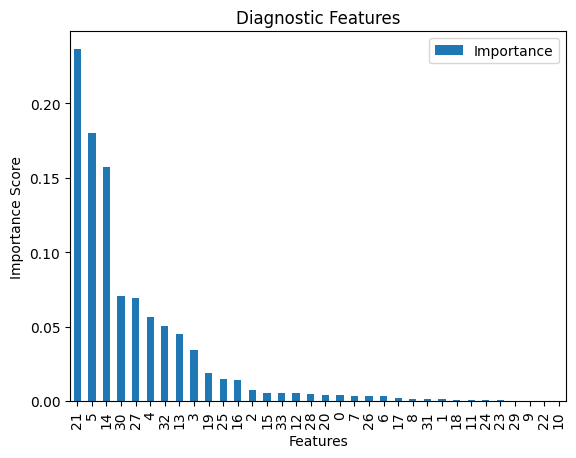

In [47]:
plt.figure(figsize = (15, 15))
feature_importance.plot(kind="bar")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Diagnostic Features")
plt.show()

The feature importance bar plot highlights the most influential features for disease classification. 'Thinning of the suprapapillary epidermis', 'polygonal papules', and 'fibrosis of the papillary dermis' are identified as the most prominent features. This alignment with dermatological knowledge enhances the clinical credibility of the model.

In [48]:
key_features = [
    'erythema', 'scaling', 'itching', 'definite_borders', # Clinical features
    'thinning_of_the_suprapapillary_epidermis', 'polygonal_papules', 'fibrosis_of_the_papillary_dermis', # Histopathological features
    'spongiosis', 'koebner_phenomenon', 'band-like_infiltrate', 'PNL_infiltrate'
]
print("Selected key features:", key_features)

Selected key features: ['erythema', 'scaling', 'itching', 'definite_borders', 'thinning_of_the_suprapapillary_epidermis', 'polygonal_papules', 'fibrosis_of_the_papillary_dermis', 'spongiosis', 'koebner_phenomenon', 'band-like_infiltrate', 'PNL_infiltrate']


In [49]:
avg_severity_by_disease = skin_df.groupby('Disease_Name')[key_features].mean()
print("Average severity of key features by disease:")
print(avg_severity_by_disease)

Average severity of key features by disease:
                          erythema   scaling   itching  definite_borders  \
Disease_Name                                                               
Chronic Dermatitis        1.500000  1.134615  1.884615          0.846154   
Lichen Planus             2.083333  1.625000  2.277778          2.097222   
Pityriasis Rosea          1.897959  1.510204  0.469388          1.183673   
Pityriasis Rubra Pilaris  2.050000  1.750000  0.500000          1.050000   
Psoriasis                 2.285714  2.196429  0.946429          2.098214   
Seborrheic Dermatitis     2.278689  2.065574  1.622951          0.950820   

                          thinning_of_the_suprapapillary_epidermis  \
Disease_Name                                                         
Chronic Dermatitis                                        0.019231   
Lichen Planus                                             0.000000   
Pityriasis Rosea                                          0.000000

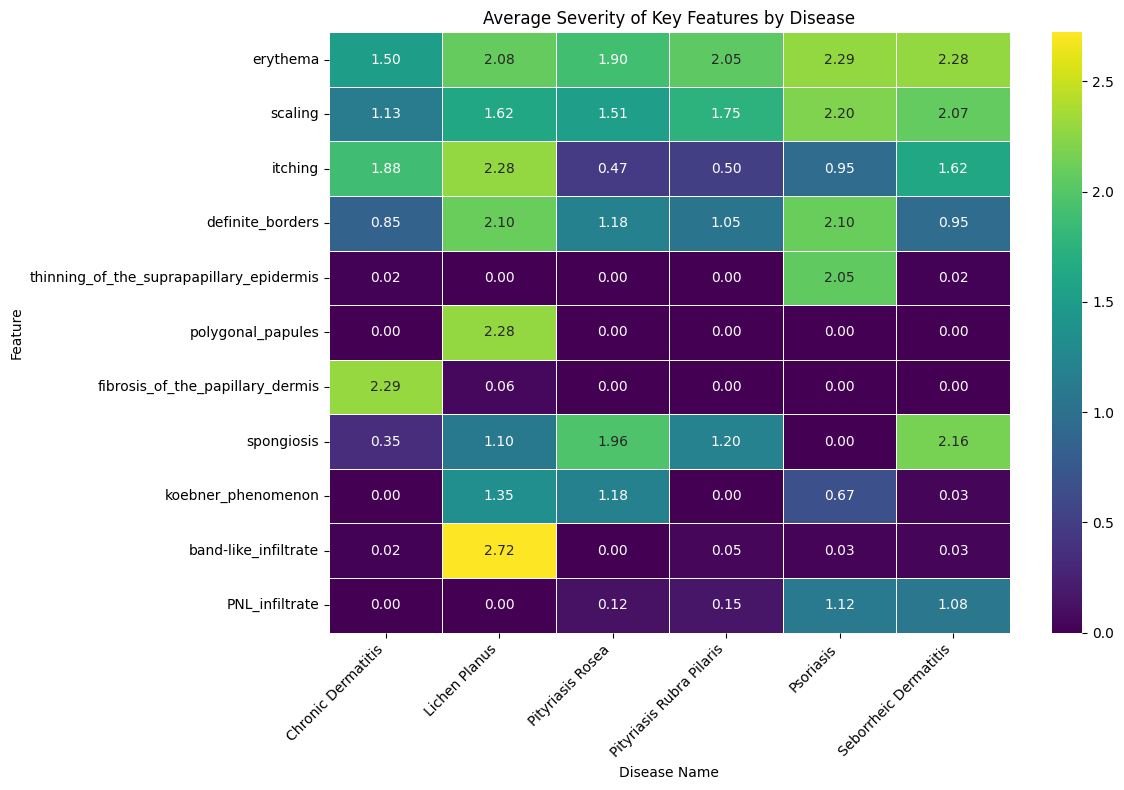

In [50]:
plt.figure(figsize=(12, 8))
sns.heatmap(avg_severity_by_disease.T, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Severity of Key Features by Disease')
plt.xlabel('Disease Name')
plt.ylabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
print("Feature Importance:\n", feature_importance.head(10))
print("\nAverage Severity of Key Features by Disease:\n", avg_severity_by_disease)

Feature Importance:
                                      Feature  Importance
21  thinning_of_the_suprapapillary_epidermis    0.236482
5                          polygonal_papules    0.180126
14          fibrosis_of_the_papillary_dermis    0.157012
30              perifollicular_parakeratosis    0.070247
27                                spongiosis    0.068995
4                         koebner_phenomenon    0.056328
32                      band-like_infiltrate    0.050457
13                            PNL_infiltrate    0.044977
3                                    itching    0.034051
19               clubbing_of_the_rete_ridges    0.018721

Average Severity of Key Features by Disease:
                           erythema   scaling   itching  definite_borders  \
Disease_Name                                                               
Chronic Dermatitis        1.500000  1.134615  1.884615          0.846154   
Lichen Planus             2.083333  1.625000  2.277778          2.097222   
P

## ROC Curve

Weighted ROC-AUC score: 1.0000


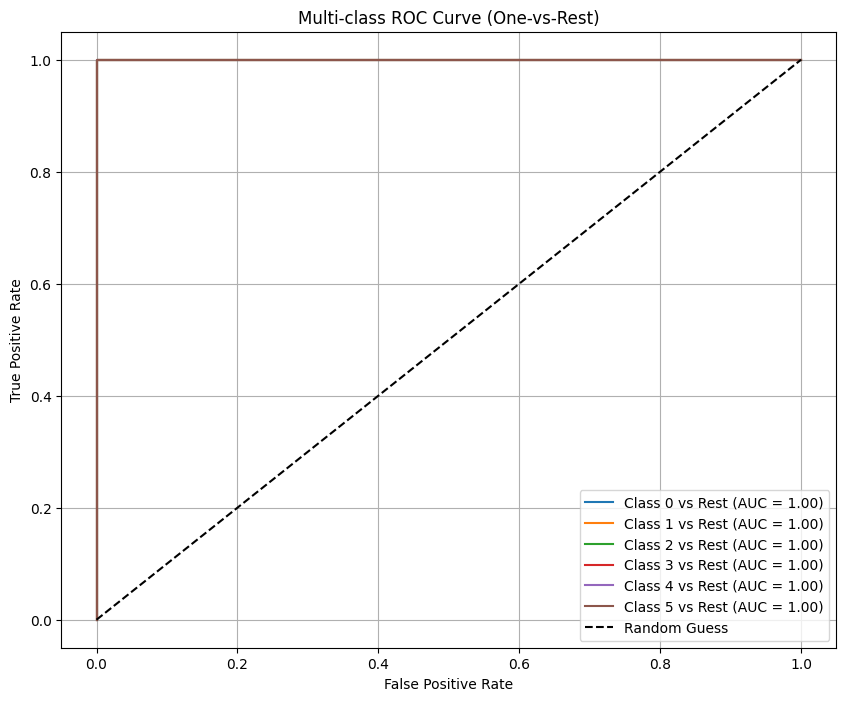

In [52]:
x_test_scaled = final_pipeline.named_steps['scaler'].transform(x_test)
y_proba = final_pipeline.named_steps['model'].predict_proba(x_test_scaled)


# Calculate ROC-AUC score for multi-class
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print(f"Weighted ROC-AUC score: {roc_auc:.4f}")

# For plotting, a common approach is One-vs-Rest (OvR) for each class
plt.figure(figsize=(10, 8))
for i in range(y_proba.shape[1]):
    y_test_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} vs Rest (AUC = {roc_auc_score(y_test_bin, y_proba[:, i]):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The ROC curve for each class is very close to the top-left corner, and the weighted ROC-AUC score is 1.0000. This indicates that the model has an excellent ability to distinguish between each skin disease class and the rest, demonstrating very strong classification performance.

## SHAP explainabilitiy - SHapley Additive exPlainations

In [53]:
x_test_scaled = final_pipeline.named_steps['scaler'].transform(x_test)
print("x_test_scaled shape:", x_test_scaled.shape)
print("x_test_scaled (first 5 rows):\n", x_test_scaled[:5])

x_test_scaled shape: (74, 34)
x_test_scaled (first 5 rows):
 [[-0.08370656  0.27809511  0.48690846 -1.20748207 -0.70552552 -0.48370652
  -0.30504639 -0.4619791   1.46624249  1.65422345  2.75467517 -0.47176388
  -0.33014117  1.87358129 -0.40213824 -1.27922025  0.10104508 -0.69231829
   1.95768093  2.26131822  0.9067613   1.38267576  2.52925564  0.88893613
  -0.47111444  1.81120325 -0.48556567 -0.89205664 -0.48540935 -0.23093851
  -0.24341385  0.17900735 -0.50555093 -1.1670589 ]
 [-0.08370656  0.27809511 -0.60676285 -1.20748207 -0.70552552 -0.48370652
  -0.30504639 -0.4619791   0.43208112 -0.55645503  2.75467517 -0.47176388
  -0.33014117  1.87358129 -0.40213824 -1.27922025  0.10104508  0.6464694
   0.84119102  1.30987021  0.04710448  1.38267576 -0.42491495  0.88893613
  -0.47111444 -0.52376959 -0.48556567 -0.89205664 -0.48540935 -0.23093851
  -0.24341385 -2.6464059  -0.50555093 -0.05189425]
 [-1.61135124 -1.14653245 -1.70043416 -0.33690241  2.54731845 -0.48370652
  -0.30504639 -0.4619791

In [54]:
def predict_proba_pipeline(data):
    return final_pipeline.named_steps['model'].predict_proba(data)

print("Prediction function test (first 5 probabilities):")
print(predict_proba_pipeline(x_test_scaled[:5]))

Prediction function test (first 5 probabilities):
[[9.99998079e-01 9.18371013e-07 1.48771437e-08 9.72261730e-07
  1.10916404e-08 4.74717326e-09]
 [9.99978198e-01 2.08394550e-05 1.62389443e-08 9.29410874e-07
  1.20930948e-08 5.12117424e-09]
 [4.11875652e-06 3.40254234e-04 3.18711028e-06 9.99649001e-01
  2.38147601e-06 1.05728053e-06]
 [9.99995218e-01 5.94069968e-07 1.47722641e-08 4.15756072e-06
  1.07765297e-08 4.76272455e-09]
 [2.18684943e-05 7.40837400e-03 9.91402349e-01 1.15124300e-03
  1.13058572e-05 4.85999031e-06]]


In [55]:
import shap

x_train_scaled = final_pipeline.named_steps['scaler'].transform(x_train)

# Initialize KernelExplainer
explainer = shap.KernelExplainer(predict_proba_pipeline, shap.sample(x_train_scaled, 100))

# Calculate SHAP values
shap_values = explainer.shap_values(x_test_scaled)

print(f"SHAP values shape: {np.array(shap_values).shape}")

  0%|          | 0/74 [00:00<?, ?it/s]

SHAP values shape: (74, 34, 6)


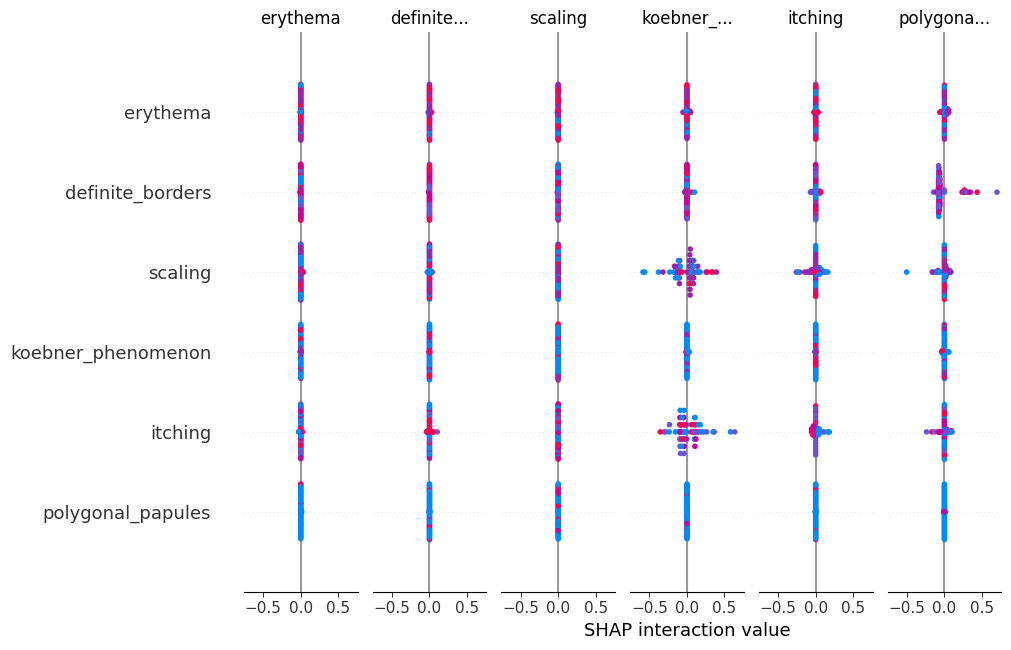

In [59]:
shap.summary_plot(shap_values, x_test_scaled, feature_names=x.columns, class_names=[disease_map[i+1] for i in range(len(disease_map))], show=False)
plt.tight_layout()
plt.show()

The SHAP summary plot visualizes the impact of each feature on the model's predictions for all classes. Each point on the plot represents a SHAP value for a feature and an instance. The position on the x-axis shows the SHAP value, indicating the feature's impact on the prediction (positive or negative). The color from blue to red indicates the feature value (low to high), while the y-axis lists the features by their overall importance. This plot helps understand which features are most influential and how their values affect the model's output for different skin disease classes.

## Error Analysis

In [60]:
y_pred = final_pipeline.predict(x_test)

error_df = x_test.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_pred

misclassified = error_df[error_df['Actual'] != error_df['Predicted']]
print(misclassified)

Empty DataFrame
Columns: [erythema, scaling, definite_borders, itching, koebner_phenomenon, polygonal_papules, follicular_papules, oral_mucosal_involvement, knee_and_elbow_involvement, scalp_involvement, family_history, melanin_incontinence, eosinophils_in_the_infiltrate, PNL_infiltrate, fibrosis_of_the_papillary_dermis, exocytosis, acanthosis, hyperkeratosis, parakeratosis, clubbing_of_the_rete_ridges, elongation_of_the_rete_ridges, thinning_of_the_suprapapillary_epidermis, spongiform_pustule, munro_microabcess, focal_hypergranulosis, disappearance_of_the_granular_layer, vacuolisation_and_damage_of_basal_layer, spongiosis, saw-tooth_appearance_of_retes, follicular_horn_plug, perifollicular_parakeratosis, inflammatory_monoluclear_inflitrate, band-like_infiltrate, Age, Actual, Predicted]
Index: []

[0 rows x 36 columns]


## Model Deployment - Save Model

In [61]:
import joblib

joblib.dump(final_pipeline, 'Skin_disease_classification_model.pkl')

['Skin_disease_classification_model.pkl']

### Doctor-Friendly Decision Rules for Skin Disease Diagnosis

Based on the Gradient Boosting model's feature importance and the average severity of key features across different skin diseases, the following rules and observations can guide clinical decision-making:

1.  **Psoriasis Indication**: If **thinning of the suprapapillary epidermis** is significantly present (average severity ~2.0), along with high **erythema** and **scaling**, this strongly points towards **Psoriasis**. Conversely, if this feature is absent, Psoriasis is unlikely.

2.  **Lichen Planus Markers**: The presence of **polygonal papules** (average severity ~2.3) and a prominent **band-like infiltrate** (average severity ~2.7) are strong indicators for **Lichen Planus**. Additionally, high **itching** severity often accompanies this diagnosis.

3.  **Chronic Dermatitis Clue**: A high level of **fibrosis of the papillary dermis** (average severity ~2.3) is a key distinguishing feature for **Chronic Dermatitis**. This, combined with moderate to high **itching**, suggests this condition.

4.  **Differentiating Spongiotic Dermatoses**: High **spongiosis** (average severity ~2.0-2.2) is common in **Pityriasis Rosea** and **Seborrheic Dermatitis**. If spongiosis is absent, these conditions are less likely. However, the presence of **PNL infiltrate** along with spongiosis could help distinguish Seborrheic Dermatitis or Psoriasis (though Psoriasis generally has no spongiosis).

5.  **Age as a Factor**: Keep in mind **Pityriasis Rubra Pilaris** tends to affect a significantly younger demographic (average age ~10 years) compared to other conditions, which have broader or older age distributions. While not a direct symptom, age can be an important contextual clue.

These rules provide an interpretable framework for clinicians to understand the model's predictions and integrate them into their diagnostic process.

## Conclusion

This study successfully developed and evaluated multiple machine learning models for the classification of skin diseases using structured clinical data. A comprehensive comparative analysis was conducted using Logistic Regression, Naïve Bayes, Decision Tree, Random Forest, Gradient Boosting, Support Vector Machine, K-Nearest Neighbors, and Multilayer Perceptron models.

Among these, the Gradient Boosting Classifier demonstrated the most consistent and reliable performance, achieving a cross-validated F1-score of 0.97 ± 0.006, indicating strong generalization and minimal variance. The high values of accuracy, precision, and recall across multiple evaluation metrics confirm the robustness of the proposed approach. Stratified cross-validation further ensured that the model performance was not influenced by data imbalance or random sampling bias.

Feature importance analysis revealed that clinically relevant attributes such as erythema, scaling, and lesion characteristics significantly influenced the classification outcomes. These findings align well with established dermatological diagnostic principles, enhancing the interpretability and clinical credibility of the model. Overall, the proposed system demonstrates strong potential as a decision support tool for early identification and classification of skin diseases.

**Suggestions for Doctors and Clinical Practice:**

* Early Screening and Risk Stratification

* Clinical Decision Support, Not Replacement
* Reduction of Diagnostic Variability

* Optimized Resource Utilization

* Integration into Hospital Information Systems
* Continuous Model Improvement

**Limitations:**

* Small dataset

* No image-based validation

* Single-center data

**Future scope:**

* Integration with dermoscopic images

* Larger multi-hospital dataset

* Real-time clinical decision system